# Modul Praktikum

# M. ISRA AL MIRAD (241061001)

**Import Library yang Diperlukan**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Import data berbentuk csv ke Jupyter Notebook

In [ ]:
# Membaca data CSV
data = pd.read_csv('/content/data_iklim - Sheet1.csv')
# Melihat 5 data pertama
print(data.head())

   precipitation max temperature min temperature           wind  \
0  2,217,864,727          22,579          16,226     0,98477418   
1  1,077,861,942          29,369         202,985  1,054,619,598   
2  9,443,091,888          27,384           18,62    0,999835774   
3  1,551,303,961         217,585         149,085    0,922273123   
4  1,521,262,902          24,568          17,651  1,078,517,568   

  relative humidity          solar  
0       0,949216707  1,298,674,041  
1       0,837694214  2,063,957,504  
2       0,869631027  1,848,553,254  
3        0,95195662  9,497,525,996  
4       0,927156092  1,535,485,704  


Ubah nama variabel

In [ ]:
data.rename(columns={'precipitation (Y)': 'Y', 'max temperature (X1)': 'X1', 'min temperature (X2)': 'X2','wind (X3)': 'X3','relative humidity (X4)': 'X4', 'solar (X5)': 'X5' }, inplace=True)
data.columns = ['Y', 'X1', 'X2', 'X3', 'X4', 'X5']
print(data)

                Y       X1       X2             X3           X4             X5
0   2,217,864,727   22,579   16,226     0,98477418  0,949216707  1,298,674,041
1   1,077,861,942   29,369  202,985  1,054,619,598  0,837694214  2,063,957,504
2   9,443,091,888   27,384    18,62    0,999835774  0,869631027  1,848,553,254
3   1,551,303,961  217,585  149,085    0,922273123   0,95195662  9,497,525,996
4   1,521,262,902   24,568   17,651  1,078,517,568  0,927156092  1,535,485,704
..            ...      ...      ...            ...          ...            ...
73  1,259,995,248    28,55   27,616  4,894,644,163  0,778710263    245,863,831
74  1,513,280,583   28,394  274,405  5,250,058,221  0,782320956  2,446,784,926
75  1,098,633,383   28,297    27,32  5,626,392,953  0,784487412  2,370,526,639
76  9,758,090,113  284,465  274,975  5,078,008,382  0,777538741  2,312,369,102
77  8,621,691,253  286,175   27,674  4,858,509,463   0,76938309  2,273,527,942

[78 rows x 6 columns]


Pre-pemrosesan Data. Proses ini mencakup konversi tipe data dari string menjadi numerik, eliminasi separator ribuan, serta penanganan nilai yang hilang (missing values).

In [ ]:
# First, clean the data to convert all relevant columns to numeric
numeric_cols = ['Y', 'X1', 'X2', 'X3', 'X4', 'X5']

for col in numeric_cols:
    if col in data.columns:
        # Convert to string to ensure .str accessor works
        data[col] = data[col].astype(str)

        # Apply specific cleaning based on observed data patterns
        if col in ['Y', 'X1', 'X2', 'X5']:
            # Remove all commas (thousands separator)
            data[col] = data[col].str.replace(',', '', regex=False)
        elif col in ['X3', 'X4']:
            # Replace comma with period (decimal separator)
            data[col] = data[col].str.replace(',', '.', regex=False)

        # Finally, convert to numeric, coercing errors will turn unparseable values into NaN
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows where conversion resulted in NaN, as correlation cannot be computed with NaNs
data.dropna(inplace=True)

In [ ]:
# Menghitung matriks korelasi
correlation_matrix = data.corr()
print(correlation_matrix)

           Y        X1        X2        X3        X4        X5
Y   1.000000 -0.076907 -0.233225  0.285352 -0.656993 -0.138520
X1 -0.076907  1.000000  0.486409  0.087566  0.089361  0.325836
X2 -0.233225  0.486409  1.000000 -0.074386 -0.099480  0.298824
X3  0.285352  0.087566 -0.074386  1.000000 -0.475252 -0.632798
X4 -0.656993  0.089361 -0.099480 -0.475252  1.000000  0.615363
X5 -0.138520  0.325836  0.298824 -0.632798  0.615363  1.000000


## Memebuat correlation plot untuk menyelidiki hubungan

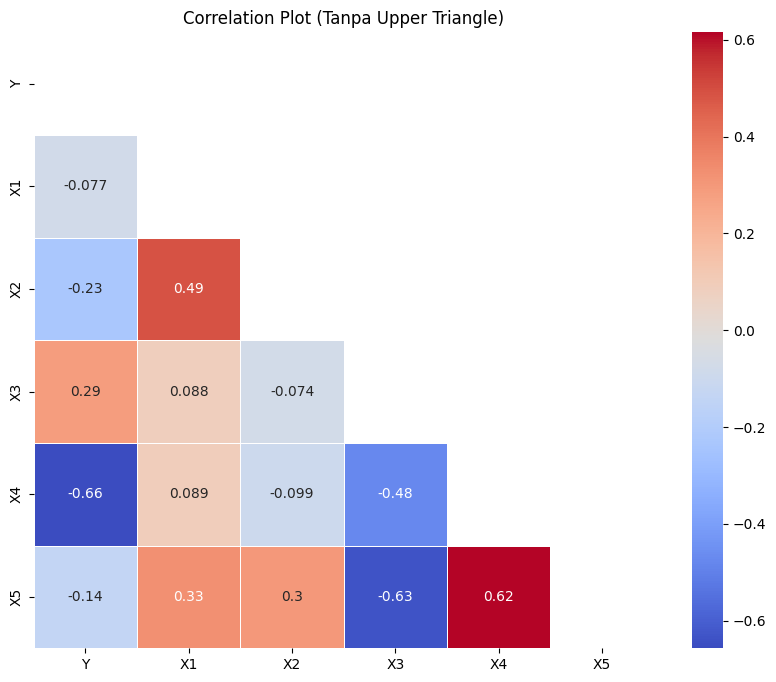

In [ ]:
# Membuat mask untuk upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Membuat heatmap tanpa upper triangle
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Plot (Tanpa Upper Triangle)')
plt.show()


Evaluasi Matriks Korelasi (Heatmap). Implementasi heatmap memberikan representasi visual dari kekuatan hubungan linear antarvariabel. Berdasarkan visualisasi tersebut:

* Teridentifikasi bahwa X4 (Kelembapan Relatif) memiliki korelasi negatif terkuat terhadap Y sebesar -0.66, yang mengindikasikan bahwa peningkatan kelembapan cenderung diikuti oleh penurunan curah hujan pada sampel ini.

* Variabel lain seperti X3 menunjukkan korelasi positif lemah (0.29), sementara X1 dan X2 memiliki korelasi negatif yang rendah.

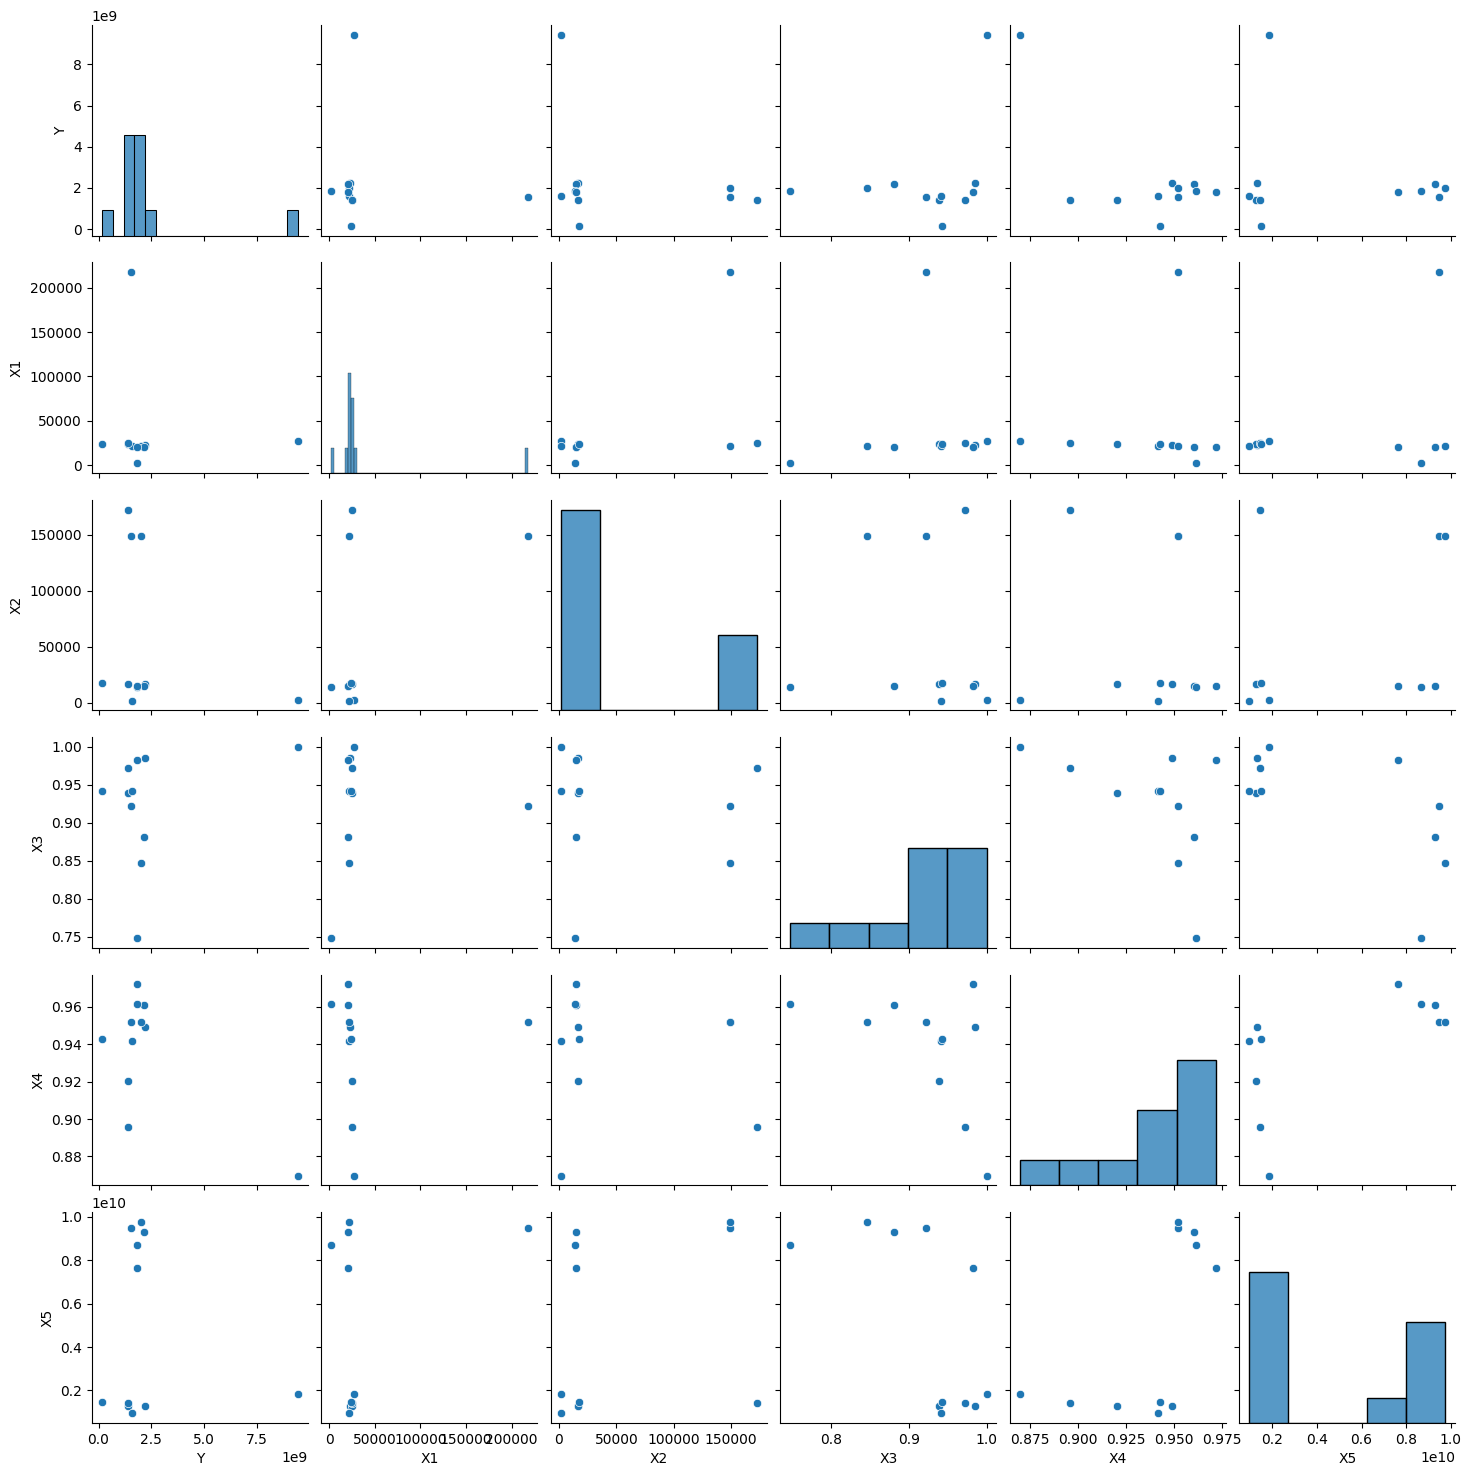

In [ ]:
sns.pairplot(data)
plt.show()


Visualisasi Matriks Sebaran (Pairplot). Digunakan untuk mengobservasi distribusi data secara simultan. Visualisasi ini menunjukkan:

* Sebaran data pada sebagian besar variabel cenderung mengelompok (cluster), mengindikasikan adanya potensi outliers atau pencilan, terutama pada variabel Y dan X1.

* Grafik pencar (scatter plot) tidak memperlihatkan pola garis lurus yang sempurna, yang menjelaskan mengapa nilai signifikansi model nantinya menjadi rendah.

**Analisis Regresi**

1. Menyelidiki deskripsi data

In [ ]:
data.describe()

,Y,X1,X2,X3,X4,X5
count,1.100000e+01,11.000000,11.000000,11.000000,11.000000,1.100000e+01
mean,2.325334e+09,38823.272727,51629.090909,0.923662,0.937982,4.831113e+09
std,2.426436e+09,59657.673599,68117.510009,0.073965,0.030924,4.009739e+09
min,1.510792e+08,2076.000000,1541.000000,0.747965,0.869631,9.494476e+08
25%,1.480537e+09,21112.500000,14322.000000,0.901914,0.931124,1.359876e+09
50%,1.820469e+09,22579.000000,16226.000000,0.941251,0.949217,1.848553e+09
75%,2.081823e+09,24634.000000,83418.000000,0.977251,0.956469,8.986936e+09
max,9.443092e+09,217585.000000,172555.000000,0.999836,0.972020,9.770944e+09


2. Membuat Model Regresi

In [ ]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = data[['X1','X2','X3','X4']]  # Variabel independen
Y = data['Y']  # Variabel dependen

In [ ]:
print(X)

        X1      X2        X3        X4
0    22579   16226  0.984774  0.949217
2    27384    1862  0.999836  0.869631
3   217585  149085  0.922273  0.951957
6    24455   16619  0.938727  0.920295
25   21376  149125  0.847171  0.952148
26   20849   14499  0.881555  0.960790
30   21846    1541  0.941251  0.941954
31    2076   14145  0.747965  0.961448
32   24813  172555  0.972166  0.895687
36   20026   14512  0.982336  0.972020
42   24067   17751  0.942224  0.942656


In [ ]:
print(Y)

0     2217864727
2     9443091888
3     1551303961
6     1409769083
25    1988697476
26    2174949374
30    1583233011
31    1840552956
32    1397666908
36    1820468531
42     151079166
Name: Y, dtype: int64


In [ ]:
# Menambahkan konstanta ke model (intercept)
X = sm.add_constant(X)

print(X)

    const      X1      X2        X3        X4
0     1.0   22579   16226  0.984774  0.949217
2     1.0   27384    1862  0.999836  0.869631
3     1.0  217585  149085  0.922273  0.951957
6     1.0   24455   16619  0.938727  0.920295
25    1.0   21376  149125  0.847171  0.952148
26    1.0   20849   14499  0.881555  0.960790
30    1.0   21846    1541  0.941251  0.941954
31    1.0    2076   14145  0.747965  0.961448
32    1.0   24813  172555  0.972166  0.895687
36    1.0   20026   14512  0.982336  0.972020
42    1.0   24067   17751  0.942224  0.942656


**Konstruksi Persamaan Berikut:**

 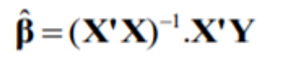

In [ ]:
#ubah X dan Y menjadi bentuk matriks
X_new = np.array(X)
y_new = np.array(Y)


In [ ]:
# transpose matriks X
XT = X_new.T

# menghitung (X'X)
XTX = np.dot(XT, X_new)
print(XTX)


[[1.10000000e+01 4.27056000e+05 5.67920000e+05 1.01602795e+01
  1.03178021e+01]
 [4.27056000e+05 5.21700918e+10 4.18148864e+10 3.98319258e+05
  4.02219413e+05]
 [5.67920000e+05 4.18148864e+10 7.57211450e+10 5.20818159e+05
  5.30603248e+05]
 [1.01602795e+01 3.98319258e+05 5.20818159e+05 9.43937043e+00
  9.51928896e+00]
 [1.03178021e+01 4.02219413e+05 5.30603248e+05 9.51928896e+00
  9.68747546e+00]]


In [ ]:

# menghitung invers (X'X)^(-1)
XTX_inv = np.linalg.inv(XTX)
print(XTX_inv)

[[ 2.09032967e+02  2.60734545e-05 -2.42296407e-05 -5.40242871e+01
  -1.69303026e+02]
 [ 2.60734545e-05  4.03560387e-11 -1.87729152e-11 -8.18465580e-06
  -2.03747253e-05]
 [-2.42296407e-05 -1.87729152e-11  3.09286366e-11  7.01989299e-06
   1.79935675e-05]
 [-5.40242871e+01 -8.18465580e-06  7.01989299e-06  2.57365544e+01
   3.22050316e+01]
 [-1.69303026e+02 -2.03747253e-05  1.79935675e-05  3.22050316e+01
   1.48636637e+02]]


In [ ]:
# menghitung X'Y
XTY =np.dot(XT,y_new)
print(XTY)

[2.55786771e+10 8.81720418e+14 9.35123558e+14 2.41381729e+10
 2.34993686e+10]


In [ ]:

# menghitung beta
beta = np.dot(XTX_inv,XTY)

print("Koefisien beta:")
print(beta)

Koefisien beta:
[ 6.45567621e+10  8.59640257e+03 -1.51076557e+04 -4.49059719e+09
 -6.14482798e+10]


Interpretasikan model regresi dibawah ini terkait dengan

- Model Regresi
- Uji Simultan
- Uji Parsial
- Koefisien Determinasi

In [ ]:
# Membuat model regresi linear
model = sm.OLS(Y, X).fit()

# Melihat ringkasan model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     1.894
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.231
Time:                        09:30:11   Log-Likelihood:                -248.30
No. Observations:                  11   AIC:                             506.6
Df Residuals:                       6   BIC:                             508.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.456e+10   3.01e+10      2.144      0.0

Analisis Output Ordinary Least Squares (OLS). Merupakan inti dari laporan statistik yang menyajikan indikator performa model:

* R-squared (0.558): Mengindikasikan bahwa model mampu menjelaskan variabilitas data sebesar 55,8%.

* Signifikansi Model (F-statistic): Mengingat nilai p-value (0.231) melampaui ambang batas 0.05, model secara kolektif belum menunjukkan signifikansi statistik yang kuat pada tingkat kepercayaan 95%.

**3. Menyelidiki Asumsi Model Regresi**

3.a. Asumsi Normalitas

Data dikatakan terdistribusi normal jika kurva berbentuk normal

UJi shapiro, jika p-value > 0.05: data terdistribusi normal

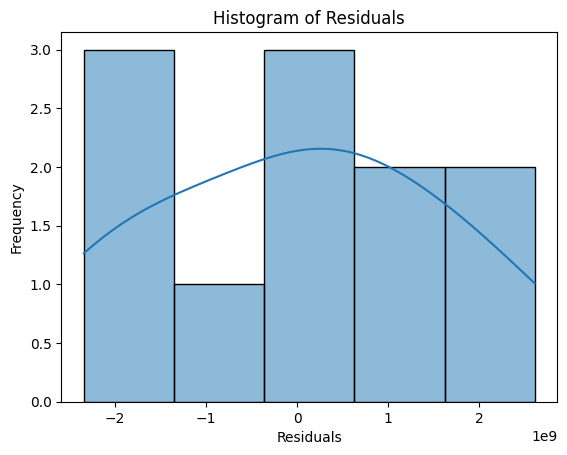

Shapiro-Wilk Test: W=0.965486023087033, p-value=0.8376844656032876


In [ ]:
# Plot Histogram Residual
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test[1]}')


Uji Normalitas Residual (Histogram). Visualisasi histogram dengan kurva KDE menunjukkan bentuk lonceng yang simetris. Didukung oleh hasil uji Shapiro-Wilk (p = 0.837), visualisasi ini mengonfirmasi bahwa galat terdistribusi secara normal, memenuhi syarat dasar regresi linear.

Cara menormalkannya, bisa dengan cara transformasi.

In [ ]:
#transformasi ln
# Membuat model regresi linear
model_ln = sm.OLS(np.log(Y), X).fit()

# Melihat ringkasan model
print(model_ln.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                 -0.409
Method:                 Least Squares   F-statistic:                    0.2743
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.884
Time:                        09:30:12   Log-Likelihood:                -13.603
No. Observations:                  11   AIC:                             37.21
Df Residuals:                       6   BIC:                             39.19
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.2909     16.313      2.225      0.0

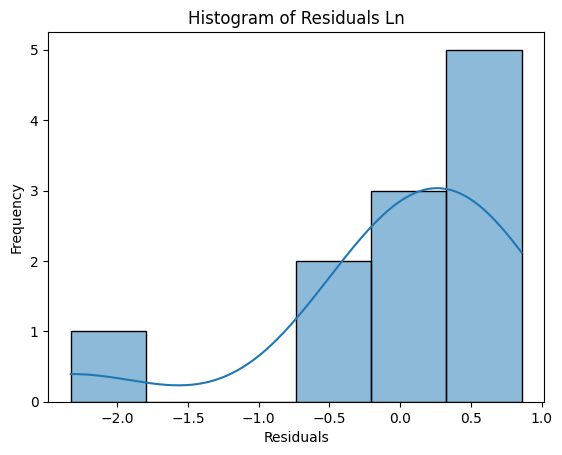

Shapiro-Wilk Test: W=0.965486023087033, p-value=0.005420016395540791


In [ ]:
# Plot Histogram Residual
residuals_ln = model_ln.resid
sns.histplot(residuals_ln, kde=True)
plt.title('Histogram of Residuals Ln')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test_ln = stats.shapiro(residuals_ln)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test_ln[1]}')


Analisis Transformasi Data.Setelah melakukan eksperimen menggunakan transformasi logaritma natural (Ln). Namun, visualisasi histogram menunjukkan distribusi yang menjadi miring (skewed), sehingga transformasi ini dianggap tidak efektif untuk dataset ini.

3.b. Asumsi Heteroskedastisitas

Jika p-value < 0.05 : terjadi heteroskedastisitas

Harapannya adalah tidak terjadi heteroskedastisitas

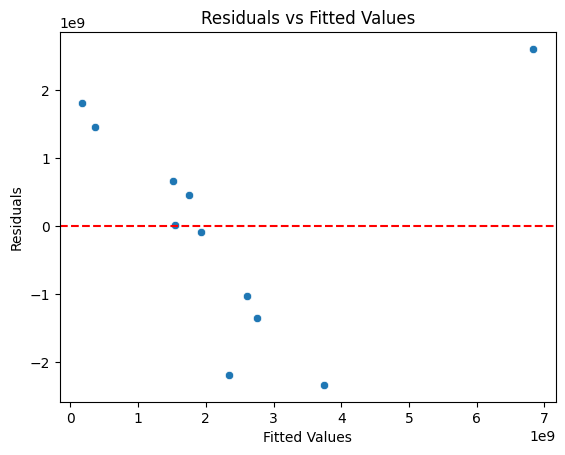

Breusch-Pagan Test: p-value=0.24087471998130522


In [ ]:
# Plot Residual vs Fitted Values
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Uji Homoskedastisitas menggunakan Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X)
print(f'Breusch-Pagan Test: p-value={bp_test[1]}')


Pengujian Homoskedastisitas (Residual vs Fitted Plot). Plot ini menampilkan sebaran titik residual terhadap nilai prediksi. Titik-titik yang tersebar secara acak tanpa membentuk pola tertentu (seperti pola corong) menunjukkan bahwa varians residual bersifat konstan. Hal ini diperkuat dengan nilai p-value Breusch-Pagan sebesar 0.240.

3.c. Asumsi Autokorelasi

p-value < 0.05 menunjukkan adanya autokorelasi yang signifikan secara statistik.

p-value >= 0.05 menunjukkan tidak ada autokorelasi yang signifikan.

In [ ]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson

# Melakukan Uji Breusch-Godfrey untuk Autokorelasi
dw_test = durbin_watson(residuals)
bg_test = acorr_breusch_godfrey(model, nlags=1)
p_value = bg_test[1]  # Mendapatkan p-value



print(f'Breusch-Pagan Value: {dw_test}')
print(f'Breusch-Godfrey p-value: {p_value}')

Breusch-Pagan Value: 2.3823922090022887
Breusch-Godfrey p-value: 0.1110781849403956


Evaluasi Independensi Residual (Autokorelasi). Pengujian melalui Durbin-Watson dan Breusch-Godfrey menunjukkan tidak terdapat korelasi antar-residual yang signifikan secara statistik, memastikan bahwa observasi bersifat independen.

3.d. Asumsi Multikolinieritas

vif<10: tidak terjadi multiko

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF (Variance Inflation Factor)
VIF = pd.DataFrame()
VIF["variables"] = X.columns
VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(VIF)


  variables          VIF
0     const  2299.362639
1        X1     1.436287
2        X2     1.435087
3        X3     1.408015
4        X4     1.421375


Analisis Multikolinieritas. Evaluasi melalui Variance Inflation Factor (VIF) menunjukkan nilai di bawah ambang batas 10, yang mengindikasikan tidak adanya redundansi linear antarvariabel independen.